# Metody oparte o sąsiedztwo

## Wstęp

Laboratorium składa się z 2 części:
1. kNN w uczeniu nadzorowanym
2. Wyszukiwanie

W pierwszej części użyjemy standardowych bibliotek oraz dodatkowo `usearch`, implementującego algorytm HNSW do approximate nearest neighbors (ANN).

W drugiej części natomiast do wektoryzacji obiektów użyjemy stosu do uczenia głębokiego opartego o PyTorch i Sentence Transformers - biblioteki implementującej transformery do uczenia nienadzorowanego i wyszukiwania.

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Zbiór danych - klasyfikacja danych numerycznych

Wykorzystamy zbiór danych [Codon usage](https://archive.ics.uci.edu/ml/datasets/Codon+usage) z dziedziny bioinformatyki. Został on zaprezentowany w artykule:

Hallee, Logan, and Bohdan B. Khomtchouk. *"Machine learning classifiers predict key genomic and evolutionary traits across the kingdoms of life."* Scientific Reports 13.1 (2023): 2088. [link](https://www.nature.com/articles/s41598-023-28965-7)

Autorzy wykonywali na nim wiele analiz, ale nas interesuje podstawowa - przewidywanie, z jakiego królestwa (kingdom) pochodzi komórka, na podstawie rozkładu kodonów w jej sekwencjonowanym RNA. Analiza DNA oraz RNA jest podstawowym zadaniem bioinformatyki. Kodony (codons) to trójki nukleotydów, np. UGC, i większość zapisuje pewien aminokwas (z wyjątkiem trzech kodonów stopu), który jest wykorzystywany w syntezie białek.

Problem jest taki, że w praktyce trzeba sekwencjonować DNA/RNA z wielu komórek, więc trzeba je namnożyć w laboratorium. Niestety nie da się uzyskać idealnej czystości, i zawsze jest szansa, że próbka zostanie zanieczyszczona, np. bakteriami. Wtedy oprócz interesujących nas komórek (np. zwierzęcych) otrzymamy inne, których trzeba się pozbyć przed dalszą analizą. Tutaj właśnie wchodzi ML - dokonamy klasyfikacji, z jakiego królestwa (a właściwie domeny) pochodzi kod RNA, żeby pomóc w takich sytuacjach.

Dla uproszczenia, autorzy, zamiast klasyfikować królestwo, klasyfikują [domenę](https://pl.wikipedia.org/wiki/Domena_(biologia)) organizmu. Są to jednostki o poziom wyżej w systematyce taksonomicznej. Do tego dokładamy wirusy i bakteriofagi. Mamy zatem klasy:
1. Archaea ([archeony](https://pl.wikipedia.org/wiki/Archeony)) - drobne jednokomórkowce, źródło ważnych [enzymów stosowanych w biologii molekularnej](https://en.wikipedia.org/wiki/Archaea#Significance_in_technology_and_industry)
2. Bacteria ([bakterie](https://pl.wikipedia.org/wiki/Bakterie))
3. Eukariota ([eukarionty](https://pl.wikipedia.org/wiki/Eukarionty)) - między innymi ludzie
4. Viruses ([wirusy](https://pl.wikipedia.org/wiki/Wirusy)) - nie są organizmami żywymi, więc nie są częścią typowej taksonomii, ale są ważne w badaniach mikrobiologicznych
5. Bacteriophages ([bakteriofagi](https://pl.wikipedia.org/wiki/Bakteriofag)) - rodzaj wirusów atakujących tylko bakterie, używane m.in. [w badaniach nad mikrobiomem jelitowym](https://kids.frontiersin.org/articles/10.3389/frym.2019.00146)

Szczegółowy opis zbioru znajduje się [na stronie UCI](https://archive.ics.uci.edu/ml/datasets/Codon+usage). W skrócie:
1. `Kingdom` - królestwo, z którego pochodzi komórka. Podział jest tutaj dość szczegółowy, ale organizmy te można pogrupować w praktyce na bakterie (bacteria), wirusy (viruses) i eukarionty (eukariota).
2. `DNAtype` - używana w innych analizach w artykule.
3. `SpeciesID` - numer gatunku.
4. `Ncodons` - liczba kodonów zmierzona dla danej komórki.
5. `SpeciesName` - nazwa gatunku.

Dalsze kolumny to znormalizowany ułamek kodonów poszczególnych typów w RNA danej komórki. W związku z tym, że dane są już znormalizowane, nie ma potrzeby ich skalowania.

In [14]:
df = pd.read_csv("codon_usage.csv")
df

/tmp/ipykernel_8201/2756931748.py:1: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("codon_usage.csv")


,Kingdom,DNAtype,SpeciesID,Ncodons,SpeciesName,UUU,UUC,UUA,UUG,CUU,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA
0,vrl,0,100217,1995,Epizootic haematopoietic necrosis virus,0.01654,0.01203,0.00050,0.00351,0.01203,...,0.00451,0.01303,0.03559,0.01003,0.04612,0.01203,0.04361,0.00251,0.00050,0.00000
1,vrl,0,100220,1474,Bohle iridovirus,0.02714,0.01357,0.00068,0.00678,0.00407,...,0.00136,0.01696,0.03596,0.01221,0.04545,0.01560,0.04410,0.00271,0.00068,0.00000
2,vrl,0,100755,4862,Sweet potato leaf curl virus,0.01974,0.0218,0.01357,0.01543,0.00782,...,0.00596,0.01974,0.02489,0.03126,0.02036,0.02242,0.02468,0.00391,0.00000,0.00144
3,vrl,0,100880,1915,Northern cereal mosaic virus,0.01775,0.02245,0.01619,0.00992,0.01567,...,0.00366,0.01410,0.01671,0.03760,0.01932,0.03029,0.03446,0.00261,0.00157,0.00000
4,vrl,0,100887,22831,Soil-borne cereal mosaic virus,0.02816,0.01371,0.00767,0.03679,0.01380,...,0.00604,0.01494,0.01734,0.04148,0.02483,0.03359,0.03679,0.00000,0.00044,0.00131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13023,pri,0,9601,1097,Pongo pygmaeus abelii,0.02552,0.03555,0.00547,0.01367,0.01276,...,0.00820,0.01367,0.01094,0.01367,0.02279,0.02005,0.04102,0.00091,0.00091,0.00638
13024,pri,1,9601,2067,mitochondrion Pongo pygmaeus abelii,0.01258,0.03193,0.01984,0.00629,0.01451,...,0.00145,0.00000,0.00048,0.00194,0.01306,0.01838,0.00677,0.00242,0.00097,0.01887
13025,pri,1,9602,1686,mitochondrion Pongo pygmaeus pygmaeus,0.01423,0.03321,0.01661,0.00356,0.01127,...,0.00000,0.00000,0.00000,0.00178,0.01661,0.02788,0.00297,0.00356,0.00119,0.02017
13026,pri,0,9606,40662582,Homo sapiens,0.01757,0.02028,0.00767,0.01293,0.01319,...,0.01142,0.01217,0.01196,0.02178,0.02510,0.02896,0.03959,0.00099,0.00079,0.00156


Mamy warning co do typu - niedobrze. Sprawdźmy typy:

In [15]:
df.dtypes.head(20)

,0
Kingdom,object
DNAtype,int64
SpeciesID,int64
Ncodons,int64
SpeciesName,object
UUU,object
UUC,object
UUA,float64
UUG,float64
CUU,float64


Kolumny `UUU` i `UUC` powinny być floatami - niedobrze. Na szczęście to tylko literówka w jednym wierszu, co można sprawdzić w danych. Usuniemy ją po prostu.

In [16]:
df = df[pd.to_numeric(df["UUU"], errors="coerce").notnull()].copy()

df = df.copy()  # to avoid irritating SettingWithCopyWarning

df["UUU"] = df.loc[:, "UUU"].astype(float)
df["UUC"] = df.loc[:, "UUC"].astype(float)

df.dtypes.head(20)

,0
Kingdom,object
DNAtype,int64
SpeciesID,int64
Ncodons,int64
SpeciesName,object
UUU,float64
UUC,float64
UUA,float64
UUG,float64
CUU,float64


**Zadanie 1 (1.5 punktu)**

1. Usuń wiersze mające mniej niż 1000 kodonów
2. Usuń wiersze dla plazmidów (wartość `plm` dla królestwa)
3. Usuń kolumny bezużyteczne dla ML: `DNAtype`, `SpeciesID`, `Ncodons`, `SpeciesName`
4. Zakoduj klasy (kolumna `Kingdom`):
  - 0 - archaea, `arc`
  - 1 - bacteria, `bct`
  - 2 - eukaryota, `pln`, `inv`, `vrt`, `mam`, `rod`, `pri`
  - 3 - bacteriophages (phages), `phg`
  - 4 - viruses (viral cells), `vrl`
5. Wyodrębnij klasy jako osobną zmienną `y`. Pamiętaj o usunięciu tej kolumny z oryginalnego DataFrame'a.
6. Narysuj wykres rozkładu klas:
   - wykres słupkowy (bar plot)
   - na osi X mają być nazwy klas pod słupkami, wypisane poziomo
   - wartości na osi Y mają być w procentach (znormalizowane 0-100)
   - pamiętaj o tytule oraz opisaniu osi

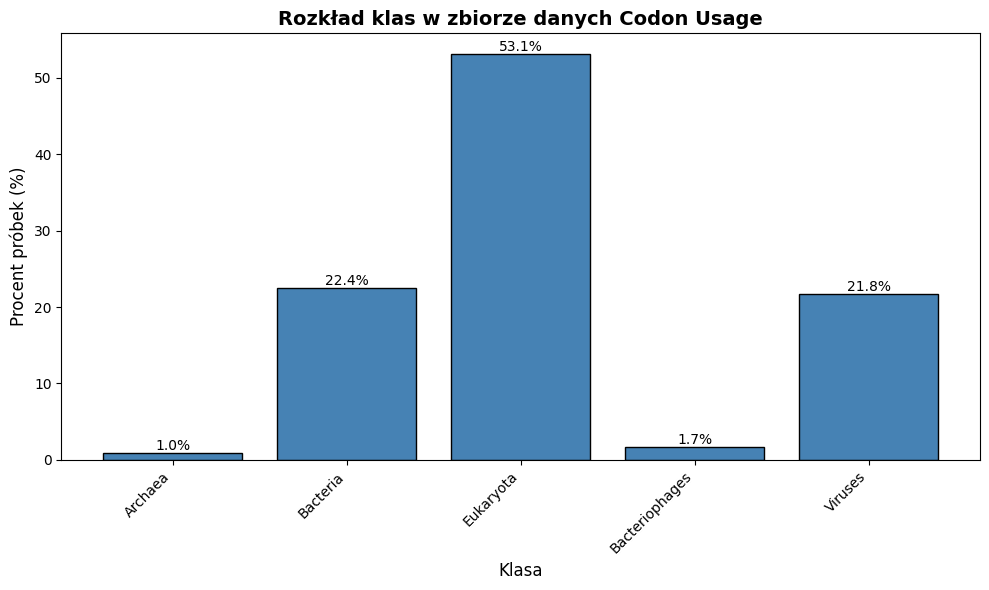

In [17]:
# 1.
df = df[df['Ncodons'] >= 1000].copy()

# 2.
df = df[df['Kingdom'] != 'plm']

# 3. Usuń kolumny bezużyteczne
df = df.drop(columns=['DNAtype', 'SpeciesID', 'Ncodons', 'SpeciesName'])

# 4.
kingdom_mapping = {
    'arc': 0,
    'bct': 1,
    'pln': 2,
    'inv': 2,
    'vrt': 2,
    'mam': 2,
    'rod': 2,
    'pri': 2,
    'phg': 3,
    'vrl': 4,
}
y = df['Kingdom'].map(kingdom_mapping)

# 5.
df = df.drop(columns=['Kingdom'])

# 6.
class_names = ['Archaea', 'Bacteria', 'Eukaryota', 'Bacteriophages', 'Viruses']
class_counts = y.value_counts().sort_index()
class_percentages = (class_counts / len(y)) * 100

ax = plt.figure(figsize=(10, 6))
bars = plt.bar(class_names, class_percentages, color='steelblue', edgecolor='black')
plt.title('Rozkład klas w zbiorze danych Codon Usage', fontsize=14, fontweight='bold')
plt.xlabel('Klasa', fontsize=12)
plt.ylabel('Procent próbek (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


Jak widać, mamy nie tylko klasyfikację wieloklasową, ale na dodatek klasyfikację niezbalansowaną. W takim przypadku trzeba użyć odpowiednich metryk. Wzorując się na artykule, użyjemy **macro-averaged F1-score**. Jest to proste rozwinięcie F1-score na wiele klas.

Dla przypomnienia, w klasyfikacji binarnej, F1-score to średnia harmoniczna precyzji (precision) i czułości (recall):

$$
F1 = \frac{2}{recall^{-1} + precision^{-1}} = 2 * \frac{precision * recall}{precision + recall} = \frac{2 * TP}{2 * TP + FP + FN}
$$

Macro-averaging oznacza, że najpierw obliczamy F1-score dla każdej klasy, a później bierzemy ich średnią. Żeby taka średnia była wysoka, to musimy mieć wysoki wynik na wszystkich 5 klasach, w tym 2 mniejszościowych, więc uwzględnimy niezbalansowanie klas.

## Klasyfikator kNN

Wytrenujemy teraz podstawowy algorytm k najbliższych sąsiadów, korzystając z samych wartości domyślnych ze Scikit-learn: 5 sąsiadów, metryka euklidesowa, brak ważenia.

Zgodnie z artykułem, wykorzystamy zwykłą metodę holdout do testowania, dzieląc zbiór na treningowy i testowy w proporcjach 80%-20%. Zrobimy to ze **stratyfikacją (stratification)**, czyli tak, żeby rozkład klas był taki sam w obu podzbiorach.

In [18]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=0, stratify=y
)

In [19]:
from sklearn.metrics import f1_score
from sklearn.neighbors import KNeighborsClassifier


clf = KNeighborsClassifier(n_jobs=-1)
clf.fit(X_train, y_train)

y_pred_score_train = clf.predict(X_train)
y_pred_score_test = clf.predict(X_test)

f1_train = f1_score(y_train, y_pred_score_train, average="macro")
f1_test = f1_score(y_test, y_pred_score_test, average="macro")

print(f"F1 train: {100 * f1_train:.2f}%")
print(f"F1 test: {100 * f1_test:.2f}%")

F1 train: 92.51%
F1 test: 91.35%


Wyniki są całkiem niezłe, ale jest jeszcze miejsce na poprawę. Być może zmiana liczby sąsiadów albo metryki, albo też dodanie ważenia sąsiadów da nam jeszcze kilka procent.

W przypadku wielu klas samo agregowane F1 nie zawsze mówi jednak wszystko. Zawsze warto sprawdzić **macierz pomyłek (confusion matrix)**. Co ważne, można ją rysować albo z surową liczbą przykładów, albo znormalizować, żeby dostać wyniki w ułamku (zakres wartości 0-1). Pierwsza możliwość jest przydatna, kiedy mamy niezbalansowane klasy i patrzymy na ogólną jakość klasyfikatora. Znormalizowane wykresy są z kolei przydatne, kiedy przyglądamy się klasom z osobna.

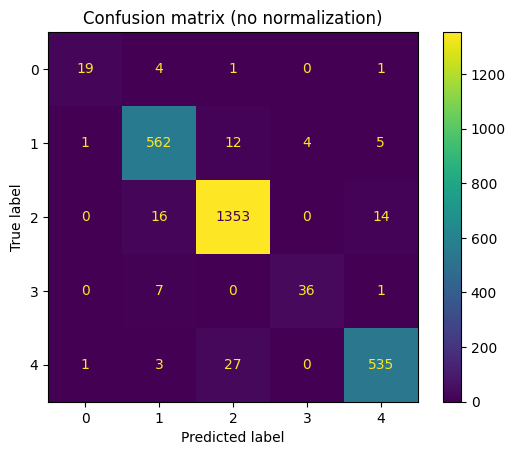

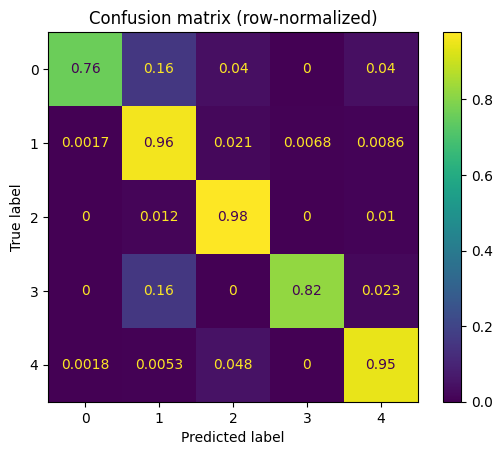

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
plt.title("Confusion matrix (no normalization)")
plt.show()


ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, normalize="true")
plt.title("Confusion matrix (row-normalized)")
plt.show()

Wyniki są całkiem niezłe, w końcu mamy wysokie F1. Widać jednak, że dość często mylimy klasę 0 (archeony) oraz klasę 3 (bakteriofagi) z klasą 1 (bakterie) - jest to problematyczne, ale zrozumiałe, bo tych klas jest najmniej.

Po tuningu powinniśmy otrzymać lepsze wyniki. Na dobry początek sprawdzimy różną liczbę sąsiadów. Trzeba zwrócić uwagę, że jeżeli nasza metryka ma jakieś argumenty, to trzeba użyć funkcji `make_scorer` i przekazać wynik do `GridSearchCV`.

Zwróć też uwagę, że skoro przekazujemy `n_jobs=-1` do klasyfikatora, to grid search dostaje `n_jobs=None`, żeby mieć tyle procesów, co rdzeni procesora. Przy okazji zmierzymy też czas tuningu.

In [21]:
from time import time

from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV


clf = KNeighborsClassifier(n_jobs=-1)

param_grid = {
    "n_neighbors": list(range(1, 51)),
}

multiclass_f1 = make_scorer(
    f1_score,
    average="macro",
    greater_is_better=True,
)

cv = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring=multiclass_f1,
    cv=5,
)

time_start = time()
cv.fit(X_train, y_train)
time_end = time()

print(f"Optimal number of neighbors: {cv.best_params_['n_neighbors']}")
print(f"Tuning time: {time_end - time_start:.2f} s")

y_pred_score_train = cv.predict(X_train)
y_pred_score_test = cv.predict(X_test)

f1_train = f1_score(y_train, y_pred_score_train, average="macro")
f1_test = f1_score(y_test, y_pred_score_test, average="macro")

print(f"F1 train: {100 * f1_train:.2f}%")
print(f"F1 test: {100 * f1_test:.2f}%")

Optimal number of neighbors: 1
Tuning time: 44.96 s
F1 train: 100.00%
F1 test: 89.16%


Co ciekawe, po tuningu nie tylko nie mamy lepszego wyniku, ale wręcz przeuczamy bardziej! Tak się niestety zdarza - tuning opiera się na wyniku na zbiorze walidacyjnym, które nie zawsze są dobrą estymatą. Pewnym sposobem na ominięcie tego jest zmniejszenie zakresu dla hiperparametru. Tutaj wiemy, że:
- im mniejsza liczba sąsiadów, tym większa wariancja (mocniejszy overfitting) i na odwrót
- domyślna liczba sąsiadów to 5
- przy 4 przeuczamy mocniej

Można więc po prostu sprawdzać zakres od 5 wzwyż. Do tego czeka nas jeszcze tuning metryki i ważenia sąsiadów.

**Zadanie 2 (1.5 punktu)**

1. Dokonaj tuningu: liczby sąsiadów (zakres [5, 25]), metryki (euklidesowa, Manhattan, cosinusowa) oraz ważenia sąsiadów (brak vs ważenie odległością). Jakie są optymalne wartości hiperparametrów?
2. Zmierz czas. Czy twoim zdaniem to długo, dla zbioru, który ma ok. 10k próbek uczących?
3. Narysuj macierz pomyłek dla zbioru testowego. Czy wygląda sensownie, szczególnie dla klas mniejszościowych? Czy udało się uzyskać wynik lepszy od bazowego?

In [23]:
# Model bazowy
baseline_clf = KNeighborsClassifier(n_jobs=-1)
baseline_clf.fit(X_train, y_train)
y_pred_baseline_test = baseline_clf.predict(X_test)
baseline_f1_test = f1_score(y_test, y_pred_baseline_test, average="macro")

param_grid = {
    "n_neighbors": list(range(5, 26)),
    "metric": ["euclidean", "manhattan", "cosine"],
    "weights": ["uniform", "distance"],
}

cv = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring=multiclass_f1,
    cv=5,
    n_jobs=None,
)

time_start = time()
cv.fit(X_train, y_train)
time_end = time()

best_clf = cv.best_estimator_
y_pred_best_train = best_clf.predict(X_train)
y_pred_best_test = best_clf.predict(X_test)

best_f1_train = f1_score(y_train, y_pred_best_train, average="macro")
best_f1_test = f1_score(y_test, y_pred_best_test, average="macro")

print(f"Best hyperparameters: {cv.best_params_}")
print(f"Best CV F1: {cv.best_score_:.4f}")
print(f"Tuning time: {time_end - time_start:.2f} s")
print()
print(f"Baseline test F1: {baseline_f1_test:.4f}")
print(f"Tuned train F1:   {best_f1_train:.4f}")
print(f"Tuned test F1:    {best_f1_test:.4f}")
print(f"Test improvement vs baseline: {best_f1_test - baseline_f1_test:+.4f}")


Best hyperparameters: {'metric': 'cosine', 'n_neighbors': 6, 'weights': 'distance'}
Best CV F1: 0.9057
Tuning time: 437.69 s

Baseline test F1: 0.9135
Tuned train F1:   1.0000
Tuned test F1:    0.9153
Test improvement vs baseline: +0.0019


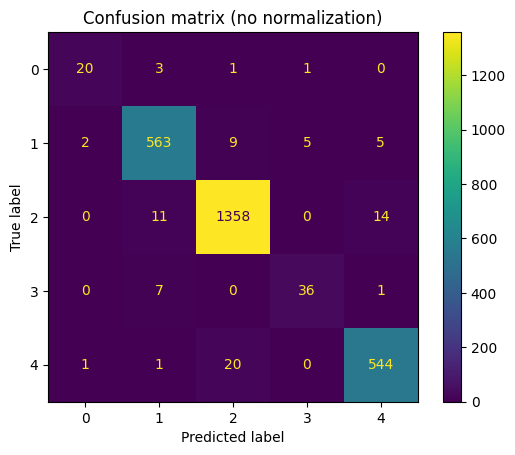

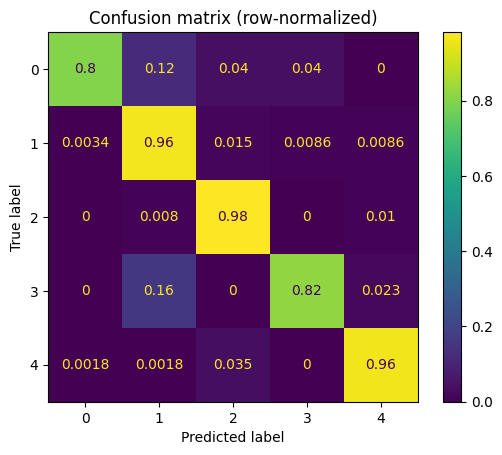

In [24]:
# Confusion matrices for tuned model
ConfusionMatrixDisplay.from_estimator(best_clf, X_test, y_test)
plt.title("Confusion matrix (no normalization)")
plt.show()

ConfusionMatrixDisplay.from_estimator(best_clf, X_test, y_test, normalize="true")
plt.title("Confusion matrix (row-normalized)")
plt.show()

Macierz pomylek dla klasy 0 i klasy 4 wyglada lepiej. Jednak róznica jest nieznaczna. Ogólnie ztunnigowany model jest niewiele lepszy od bazowego, poprawa jest na granicy szumu


## Approximate Nearest Neighbors (ANN)

Postaramy się teraz przyspieszyć nasz klasyfikator, w zamian za odrobinę dokładności, za pomocą algorytmu przybliżonych najbliższych sąsiadów, a konkretnie [HNSW](https://www.pinecone.io/learn/series/faiss/hnsw/) zaimplementowanego w bibliotece [USearch](https://github.com/unum-cloud/USearch). HNSW jest obecnie dominującym algorytmem ANN ze względu na dokładność, szybką konstrukcję, oraz relatywnie prosty algorytm.

Twórcy Scikit-learn'a zdawali sobie sprawę, że algorytmy znajdowania najbliższych sąsiadów to aktywne pole rozwoju, dlatego stworzyli klasę (i interfejs) `KNeighborsTransformer`, pozwalającą integrować zewnętrzne rozwiązania. Działa ona zarówno do klasyfikacji / regresji kNN, jak i do innych algorytmów opartych o sąsiedztwo, które budują graf najbliższych sąsiadów. W przypadku jego użycia trzeba podać `metric="precomputed"`, bo obliczaniem odległości zajmuje się osobny algorytm.

Biblioteka USearch zapewnia tylko sam indeks wyszukiwania, bez integracji ze scikit-learn, dlatego zaimplementowano ją poniżej. Klasa dziedziczy po `USearchKNeighborsTransformer`, w metodzie `.fit()` budując indeks, a w `.transform()` budując i zwracając rzadką (sparse) macierz odległości.

Wykorzystamy funkcję `make_pipeline()`, która buduje obiekt `Pipeline`, ale nie wymaga podawania nazw kolejnych elementów.

In [ ]:
from numbers import Integral

from scipy import sparse as sp
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils._param_validation import Interval, StrOptions
from sklearn.utils.validation import check_array, check_is_fitted
from usearch.index import Index


class USearchKNeighborsTransformer(BaseEstimator, TransformerMixin):
    # scikit-learn runtime validation mechanism
    _parameter_constraints: dict = {
        "n_neighbors": [Interval(Integral, 1, None, closed="left")],
        "metric": [StrOptions({"euclidean", "cosine", "jaccard", "tanimoto"})],
    }

    def __init__(self, n_neighbors: int = 5, metric: str = "euclidean"):
        self.n_neighbors = n_neighbors
        self.metric = metric

    def fit(self, X, y=None):
        self._validate_params()
        X = check_array(X, accept_sparse=False)
        self.n_samples_fit_, self.n_features_in_ = X.shape

        metric_mapping = {
            "euclidean": "l2sq",
            "cosine": "cos",
            "jaccard": "tanimoto",
            "tanimoto": "tanimoto",
        }
        is_bit_metric = self.metric in {"jaccard", "tanimoto"}

        self.index_ = Index(
            ndim=self.n_features_in_,
            metric=metric_mapping[self.metric],
            dtype="b1" if is_bit_metric else "f32",
        )
        keys = np.arange(self.n_samples_fit_, dtype=np.uint64)
        values = self._prepare_inputs(X)
        self.index_.add(keys, values)

        return self

    def transform(self, X):
        check_is_fitted(self)
        X = check_array(X)
        X = self._prepare_inputs(X)
        return self._get_sparse_graph(X, self.n_neighbors)

    def fit_transform(self, X, y=None):
        self.fit(X)
        X = self._prepare_inputs(X)

        # in fit_transform, the nearest neighbor is also the point itself (dist=0)
        # query for k+1 and filter the diagonal to match scikit-learn

        graph = self._get_sparse_graph(X, self.n_neighbors + 1)
        graph.setdiag(0.0)
        graph.eliminate_zeros()

        return graph

    def _prepare_inputs(self, X):
        if self.metric in {"jaccard", "tanimoto"}:
            return np.packbits((X > 0).astype(bool), axis=1)

        return np.ascontiguousarray(X, dtype=np.float32)

    def _get_sparse_graph(self, X, k):
        # USearch search returns a SearchMatches object with .keys and .distances
        matches = self.index_.search(np.ascontiguousarray(X), count=k)
        indices = matches.keys.flatten().astype(np.int64)
        distances = matches.distances.flatten().astype(np.float64)

        # scikit-learn expects Euclidean distance; USearch l2sq returns squared distance
        if self.metric == "euclidean":
            distances = np.sqrt(np.maximum(distances, 0))

        indptr = np.arange(0, len(X) * k + 1, k)
        output_shape = (len(X), self.n_samples_fit_)
        return sp.csr_array((distances, indices, indptr), shape=output_shape)


In [ ]:
from time import time


def benchmark_knn_and_ann(
    sklearn_knn,
    usearch_ann,
    X_train,
    X_test,
    y_train,
    y_test,
) -> None:
    # training
    start_time = time()
    sklearn_knn.fit(X_train, y_train)
    end_time = time()

    sklearn_knn_fit_time = end_time - start_time

    start_time = time()
    usearch_ann.fit(X_train, y_train)
    end_time = time()

    usearch_ann_fit_time = end_time - start_time

    # prediction

    start_time = time()
    y_pred_sklearn = sklearn_knn.predict(X_test)
    end_time = time()

    sklearn_knn_predict_time = end_time - start_time

    start_time = time()
    y_pred_usearch = usearch_ann.predict(X_test)
    end_time = time()

    usearch_ann_predict_time = end_time - start_time

    f1_knn = f1_score(y_test, y_pred_sklearn, average="macro")
    f1_ann = f1_score(y_test, y_pred_usearch, average="macro")

    print(f"Scikit-learn training time: {sklearn_knn_fit_time:.2f}")
    print(f"USearch training time: {usearch_ann_fit_time:.2f}")
    print()
    print(f"Scikit-learn prediction time: {sklearn_knn_predict_time:.2f}")
    print(f"USearch prediction time: {usearch_ann_predict_time:.2f}")
    print()
    print(f"Scikit-learn F1: {100 * f1_knn:.2f}%")
    print(f"USearch F1: {100 * f1_ann:.2f}%")


In [ ]:
from sklearn.pipeline import make_pipeline


sklearn_knn = KNeighborsClassifier(metric="euclidean")

usearch_ann = make_pipeline(
    USearchKNeighborsTransformer(metric="euclidean"),
    KNeighborsClassifier(metric="precomputed"),
)

benchmark_knn_and_ann(sklearn_knn, usearch_ann, X_train, X_test, y_train, y_test)

Czas treningu jest dłuższy - to oczekiwany wynik. ANN pozwala za to uzyskać znacznie szybszy czas predykcji niż k-d tree, zwłaszcza dla przestrzei wysokowymiarowych, utrzymując przy tym podobną dokładność.

K-d tree nie działa jednak w ogóle dla metryk nieeuklidesowych oraz przestrzeni bardzo wysokowymiarowych. Jest to częste, kiedy korzystamy z metod automatycznej ekstrakcji cech, np. w przetwarzaniu sygnałów, klasyfikacji szeregów czasowych, czy wektoryzacji grafów molekularnych.

## Zbiór danych - klasyfikacja danych chemicznych

Teraz zajmiemy się klasyfikacją zbioru posiadającego same zmienne binarne, do których trzeba użyć odpowiednich metryk. Konkretnie, będzie to zbiór [HIV z benchmarku MoleculeNet](https://moleculenet.org/datasets-1), w którym na podstawie reprezentacji chemicznej molekuły trzeba przewidywać, czy jest ona inhibitorem wirusa HIV. [Inhibitory](https://en.wikipedia.org/wiki/Reaction_inhibitor) to substancje przeciwne do katalizatorów - spowalniają lub uniemożliwiają jakieś zjawisko, w naszym wypadku infekcję wirusa HIV. Przewidywanie własności molekuł to kluczowe zadanie w nowoczesnym projektowaniu leków i bardzo ważne zastosowanie ML w farmacji i chemii molekularnej.

Zbiór jest już podzielony na treningowy, walidacyjny i testowy w ramach projektu [Open Graph Benchmark](https://ogb.stanford.edu/docs/graphprop/). Dane te można traktować jak klasyfikację grafów molekularnych, np. z pomocą grafowych sieci neuronowych. Jednak podejściem klasycznym i dającym często lepsze wyniki są **fingerprinty molekularne (molecular fingerprints)**. Są to deterministyczne algorytmy ekstrakcji cech z grafu, zamieniające go na wektor. Jest ich dużo, ale najpopularniejszy to [ECFP (Extended Connectivity FingerPrint)](https://docs.chemaxon.com/display/docs/extended-connectivity-fingerprint-ecfp.md), wykorzystujący informację o subgrafach o małym promieniu (typowo 4). Domyślnie skutkuje to cechami binarnymi, czy subgraf wystąpił, czy nie w danej molekule.

Wizualizacja, jak działa taka wektoryzacja (z [dokumentacji ChemAxon](https://docs.chemaxon.com/latest/fingerprints_extended-connectivity-fingerprint-ecfp.html)):

![image.png](attachment:b6040945-442a-49ac-8eee-b943bf9b823d.png)

![image.png](attachment:1d1090ba-c81a-43ed-8e82-fb9215efbec6.png)

Molekuły są typowo przechowywane w formacie [SMILES strings](https://en.wikipedia.org/wiki/Simplified_Molecular_Input_Line_Entry_System). Graf molekularny można odczytać z tego formatu, a potem przekazać taki zbiór do fingerprintu. Wtedy zamieniamy problem na zwykłą klasyfikację tabelaryczną. Scikit-fingerprints zrobi to automatycznie, jeżeli SMILES strings zostaną przekazane do fingerprintu.

Jako że zbiór jest ma cechy binarne, to nie ma potrzeby żadnego skalowania zmiennych. W przypadku zbioru HIV typową metryką jest Area Under Receiver Operating Characteristic (AUROC / ROC AUC).

**Zadanie 3 (1 punkt)**

1. Załaduj zbiór HIV z pomocą funkcji [load_hiv()](https://scikit-fingerprints.readthedocs.io/latest/modules/datasets/generated/skfp.datasets.moleculenet.load_hiv.html). Wypisz kilka pierwszych SMILESów.
2. Załaduj indeksy treningowe, walidacyjne i testowe z benchmarku OGB z pomocą funkcji [load_ogb_splits()](https://scikit-fingerprints.readthedocs.io/latest/modules/datasets/generated/skfp.datasets.moleculenet.load_ogb_splits.html).
3. Podziel zbiór (SMILES oraz klasy `y`) na treningowe, walidacyjne i treningowe.
4. Narysuj wykres częstości klas w zbiorze treningowym. Jak sądzisz, czemu akurat AUROC zostało tutaj wybrane jako metryka?
5. Oblicz fingerprinty ECFP z użyciem [ECFPFingerprint](https://scikit-fingerprints.readthedocs.io/latest/modules/generated/skfp.fingerprints.ECFPFingerprint.html) dla wszystkich 3 podzbiorów.

**Zadanie 4 (1.5 punktu)**

1. Wytrenuj klasyfikator kNN z domyślnymi hiperparametrami, używając metryki Jaccarda (Tanimoto). Zmierz AUROC na zbiorze testowym. Pamiętaj, żeby przekazać odpowiednie wartości do metryki (patrz [przykład w dokumentacji](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html)).
2. Zmierz czas treningu oraz predykcji. Czy podczas treningu została zbudowana jakakolwiek struktura danych?
3. Dokonaj tuningu liczby sąsiadów z zakresu [1, 5, 10]. Wykorzystaj tutaj istniejący zbiór walidacyjny z pomocą `PredefinedSplit`. Może się przydać [ta odpowiedź na StackOverflow](https://stackoverflow.com/a/70155766/9472066). Do tuningu wykorzystaj metrykę AUROC (argument `scoring`).
4. Porównaj wyniki algorytmu po tuningu z wynikami z artykułu ["Molecular Topological Profile (MOLTOP) -- Simple and Strong Baseline for Molecular Graph Classification" J. Adamczyk, W. Czech](https://arxiv.org/abs/2407.12136).

![Screenshot from 2025-03-16 09-45-50.png](attachment:59431cbf-16e9-48a6-9eab-c25cdfb4f340.png)

// skomentuj tutaj

**Zadanie 5 (1.5 punktu)**

1. Stwórz pipeline do klasyfikacji ANN z użyciem USearch. Wykorzystaj metrykę Jaccarda (Tanimoto) i znalezioną wcześniej optymalną liczbę sąsiadów.
2. Wytrenuj zwykłe kNN oraz ANN oraz dokonaj predykcji (metryka AUROC). Zmierz czas oraz dokładność obu metod. Czy twoim zdaniem warto dokonać w tym wypadku takiej aproksymacji?

## Wyszukiwanie z pomocą najbliższych sąsiadów

Naszym ostatnim zastosowaniem metod opartych o sąsiedztwo będzie wyszukiwanie przedmiotów. Konkretnie stworzymy wyszukiwarkę obrazów na podstawie wpisanego hasła.

Jest to zadanie **multimodalne (multimodal)**, bo operujemy na dwóch różnych modalnościach: obrazie i tekście. Takie wyszukiwarki działają następująco:
1. W fazie treningu przedmioty (obrazy) są wektoryzowane siecią neuronową i przechowywane w indeksie.
2. Użytkownik wpisuje tekst, który jest wektoryzowany za pomocą tej samej sieci neuronowej, dlatego musi być ona multimodalna.
3. Wyszukujemy najbliższych sąsiadów (obrazy-wektory) dla tekstu-wektora.

Najbardziej znanym modelem multimodalnym jest [CLIP](https://openai.com/research/clip), stworzony przez OpenAI. Jego architektura i wagi są dostępne publicznie, w przeciwieństwie do nowych rozwiązań tej firmy. Jest to model zasadniczo niewymagający fine-tuningu, działa bardzo dobrze w podstawowej formie dla wielu zadań. Został też wykorzystany jako element modelu [DALL-E 2](https://openai.com/product/dall-e-2).

Nie musisz szczegółowo wiedzieć, jak działa ten model, ale pewne podstawy są bardzo ciekawe i przydatne. Wysokopoziomowo architekturę dobrze opisuje [ten artykuł](https://towardsdatascience.com/clip-the-most-influential-ai-model-from-openai-and-how-to-use-it-f8ee408958b1). Dla zainteresowanych [cały artykuł](https://cdn.openai.com/papers/Learning_Transferable_Visual_Models_From_Natural_Language.pdf), znacznie bardziej szczegółowy. CLIP składa się z dwóch enkoderów: dla tekstu i dla obrazu. Są to zwykłe pre-trenowane sieci, a konkretnie:
1. Dla obrazu - [Visual Transformer (ViT)](https://www.v7labs.com/blog/vision-transformer-guide). Jest to architektura, która używa transformerów i atencji do przetwarzania obrazów. Ideą jest, żeby pociąć obraz na sąsiadujące kawałki (patches), i traktować je jak słowa dla atencji.
2. Dla tekstu - [Transformer](https://machinelearningmastery.com/the-transformer-model/), z pewnymi modyfikacjami.

Każda z tych sieci wektoryzuje wejście, dając embedding.

![clip.png](attachment:962d0174-c3a6-4e9a-83b4-21cd16fe31e0.png)

Zbiorem danych była kolekcja 400 milionów par (obraz, tekst), gdzie tekst opisywał zawartość obrazu. Następnie wykonano **constrastive pre-training** - model dostaje batch $N$ par (obraz, tekst) i ma przewidzieć, które z $N \times N$ możliwych kombinacji (obraz, tekst) faktycznie wystąpiły. W tym celu maksymalizuje podobieństwo cosinusowe par, które wystąpiły w batchu, a minimalizuje podobieństwo dla $N^2 - N$ możliwych kombinacji, których nie było w batchu. W tym celu jest używana entropia krzyżowa z pewnymi modyfikacjami.

Widać więc, że model jest nienadzorowany, a zbiór danych był ogromny, więc fine-tuning nie jest nam zasadniczo potrzebny. Można go użyć do klasyfikacji, ale tym nie będziemy się zajmować. Dodatkowo odpowiednią metryką odległości dla najbliższych sąsiadów będzie podobieństwo cosinusowe.

Biblioteka [Sentence-Transformers](https://www.sbert.net/index.html) powstała dla różnych modeli transformerowych do zadań nienadzorowanych, ale dodano do niej także bardzo wygodny interfejs dla modelu CLIP - [przykład użycia](https://www.sbert.net/examples/applications/image-search/README.html).

Jako zbiór wykorzystamy [Amazon Berkeley Objects (ABO) Dataset](https://amazon-berkeley-objects.s3.amazonaws.com/index.html) - zbiór obrazów produktów Amazona, stworzony we współpracy z University of California, Berkeley. Wykorzystamy [zminiaturyzowany zbiór](https://amazon-berkeley-objects.s3.amazonaws.com/archives/abo-images-small.tar), w którym obrazy mają rozmiar 256x256 pikseli, bo na nasze potrzeby jest zupełnie wystarczający.

**Zadanie 6 (3 punkty)**

*Wyszukiwarka z ANN*

1. Ściągnij [zbiór danych](https://amazon-berkeley-objects.s3.amazonaws.com/archives/abo-images-small.tar). Rozpakuj go obok tego notebooka. W katalogu `images/metadata` znajdziesz plik `images.csv.gz` - zawiera on ścieżki do obrazów.
2. Uzupełnij kod funkcji `vectorize_images`, która oblicza embeddingi obrazów za pomocą modelu CLIP. Przyda ci się [ten tutorial](https://www.sbert.net/examples/applications/image-search/README.html). Ustaw wartość MAX_IMAGES tak, żeby wystarczyło ci RAMu i żeby proces trwał rozsądną ilość czasu (ale co najmniej kilka-kilkanaście minut). `start_idx` oraz `end_idx` to indeksy wierszy, na których w danej chwili operujemy - po prostu przesuwamy się o `BATCH_SIZE` w pętli for.
3. Uzupełnij kod klasy `ImageSearch`:
  - w konstruktorze stwórz indeks za pomocą klasy [Index](https://unum-cloud.github.io/USearch/python/) z USearch, korzystając z metryki cosinusowej
  - w metodzie `query` zwektoryzuj zapytanie tekstowe, a następ wyszukaj indeksy najbliższych sąsiadów-obrazów w indeksie (zwróć uwagę na to, co zwraca metoda `.search()` dla indeksu), a następnie zwróć ścieżki do ich obrazów; zwróć uwagę na to, że `.query()` wymaga 2-wymiarowego wejścia, więc w naszym wypadku `(1, 512)`
  - w metodzie `show_images` załaduj i wyświetl obrazy; może się przydać [ten przykład](https://matplotlib.org/stable/gallery/axes_grid1/simple_axesgrid.html)
4. Przetestuj wyszukiwarkę kilkoma hasłami (metoda `.search()`). Prawdopodobnie najlepiej zadziałają hasła odpowiadające typowym produktom sprzedawanym w Amazonie.
5. Jakie widzisz zalety i wady takiego podejścia do wyszukiwania?

**Uwaga:** jeżeli masz mało RAMu lub pracujesz na Google Colab, to warto zrestartować Jupyter Notebooka, zamykając kernel. Zwolni ci to pamięć. Możesz też usunąć macierz z embeddingami (`del embeddings`) kiedy stworzysz indeks w konstruktorze `ImageSearch`.

In [ ]:
!wget https://amazon-berkeley-objects.s3.amazonaws.com/archives/abo-images-small.tar

In [ ]:
!tar -xf abo-images-small.tar

In [ ]:
# prepare pd.Series with paths to images
image_paths = pd.read_csv("images/metadata/images.csv.gz")

# "height" and "width" are original image size, let's select
# only large ones - they are probably more interesting
mask = (image_paths["height"] >= 1000) & (image_paths["width"] >= 1000)
image_paths = image_paths.loc[mask, :]

# remove columns, leaving only pd.Series with paths
image_paths = image_paths["path"]
image_paths = "images/small/" + image_paths.astype(str)

image_paths

In [ ]:
from itertools import islice

import joblib
import torch
from sentence_transformers import SentenceTransformer
from tqdm.notebook import tqdm


MAX_IMAGES = 50000
BATCH_SIZE = joblib.cpu_count(only_physical_cores=True)


def vectorize_images(image_paths: pd.Series) -> np.ndarray:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = SentenceTransformer("clip-ViT-B-32", device=device)

    # batch iterator, based on Python itertools example
    def batched(iterable, n: int):
        it = iter(iterable)
        while batch := tuple(islice(it, n)):
            yield batch

    # CLIP embeddings have 512 dimensions
    embeddings = np.empty((MAX_IMAGES, 512))

    # iterate with tqdm, it will give us a nice progress bar
    with tqdm(total=MAX_IMAGES) as pbar:
        start_idx = 0
        for batch in batched(image_paths.iloc[:MAX_IMAGES], BATCH_SIZE):
            # update end_idx; remember to stop at MAX_IMAGES!

            # load images with Image.open()

            # calculate embeddings

            # save embeddings in the embeddings array

            # update start_idx

            pbar.update(BATCH_SIZE)

    return embeddings

In [ ]:
embeddings = vectorize_images(image_paths)

In [ ]:
class ImageSearch:
    def __init__(self, image_paths: pd.Series, embeddings: np.ndarray):
        # change to Numpy array to avoid .iloc[] and just index with []
        self.image_paths = image_paths.values

        device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model = SentenceTransformer("clip-ViT-B-32", device=device)

        # create ANN index
        self.index = ...

    def search(self, text: str, n_neighbors: int = 9) -> None:
        image_paths = self.query(text, n_neighbors)
        self.show(image_paths)

    def query(self, text: str, n_neighbors: int = 9) -> list[str]: ...

    def show(self, image_paths: list[str]) -> None: ...

In [ ]:
image_search = ImageSearch(image_paths, embeddings)

In [ ]:
image_search.search("blue pillow")

// skomentuj tutaj

## Zadanie dodatkowe nr 1 (2 punkty)

Zaimplementuj samodzielnie w interfejsie scikit-learn klasyfikator k najbliższych sąsiadów.

Parametry:
1. `n_neighbors` - integer, liczba sąsiadów
2. `metric` - metryka odległości: "euclidean", "cosine", lub "jaccard"
3. `algorithm` - 3 opcje: brute force, k-d tree, oraz HNSW.
4. `n_jobs` - liczba wątków do użycia w przypadku brute force

Wersję brute force zaimplementuj równolegle z pomocą [biblioteki Joblib](https://joblib.readthedocs.io/en/latest/parallel.html). K-d tree jest zaimplementowane w scikit-learn w klasie [KDTree](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KDTree.html). Do HNSW użyj USearch, jak powyżej.

Dla przypomnienia, interfejs scikit-learn zakłada:
- dziedziczenie po `BaseEstimator` oraz `RegressorMixin` lub `ClassifierMixin`
- konstruktor:
  - wszystkie argumenty mają wartości domyślne
  - argumenty są zapisywane bez żadnych zmian jako atrybuty o tej samej nazwie
  - jest lekki i nie wykonuje żadnych operacji
- metoda `.fit()`:
  - przyjmuje macierz `X` oraz wektor `y`
  - wywołuje `validate_data()`
  - estymuje parametry modelu, które są tworzone w tej metodzie jako atrybuty z podkreślnikiem na końcu, np. `self.w_ = ...`
  - zwraca `self`
- metoda `.predict()`:
  - przyjmuje macierz `X`
  - wywołuje `check_is_fitted()` oraz `validate_data()`
  - dokonuje predykcji dla tych nowych punktów

Więcej szczegółów w dokumentacji - [Developing scikit-learn estimators](https://scikit-learn.org/stable/developers/develop.html).

Przetestuj poprawność swojej implementacji - wyniki powinny być podobne do tych ze scikit-learn dla tych samych hiperparametrów.

## Zadanie dodatkowe nr 2 (3 punkty)

Screening wirtualny (virtual screening, VS) to proces filtrowania ogromnych baz molekuł w celu znalezienia cząsteczek aktywnych wobec docelowego białka i receptora. Molekuły te nazywami ligandami, realizującymi wiązanie białko-ligand. [Polska wikipedia](https://pl.wikipedia.org/wiki/Screening_wirtualny) oraz [angielska](https://en.wikipedia.org/wiki/Virtual_screening) dobrze to opisują. Zgodnie z zasadą podobieństwa molekularnego (molecular similarity principle), cząsteczki podobne strukturalnie do aktywnych, już znanych ligandów także mają duże prawdopodobieństwo pożądanej aktywności biologicznej. Co ważne, musimy w takim procesie wybrać tylko niewielką liczbę molekuł wynikowych. Trafią one do laboratorium do testów, żeby zweryfikować ich faktyczną aktywność, a że takie testy są drogie, to musimy się mocno ograniczyć.

Realizacja wyszukiwania podobnych molekuł odbywa się często z użyciem algorytmów najbliższych sąsiadów. Jest to część podejścia ligand-based virtual screening (LBVS). W podejściu opartym wprost o podobieństwo molekuł (ang. similarity searching) kroki są następujące:
1. Podział zbioru na treningowy i testowy.
2. Ze zbioru treningowego zostawiamy tylko klasę pozytywną, czyli molekuły aktywne.
3. Wektoryzujemy wszystkie molekuły, np. fingerprintami molekularnymi.
4. Dla każdej cząsteczki ze zbioru testowego liczymy podobieństwo do aktywnych ze zbioru treningowego. Agregujemy
   te wartości np. funkcją maximum (MAX fusion) czy średnią (MEAN fusion).
5. Sortujemy molekułu testowe malejąco, czyli na początku listy będą te, które z najwyższym prawdopodobieństwem są aktywne.
6. Ewaluujemy je według zadanej metryki.

Metryki jakości w tym problemie uwzględniają fakt, że kluczowe jest, żeby na samym początku listy było jak najwiękcej naprawdę aktywnych molekuł. Chcemy zmaksymalizować zysk z wyboru tej niewielkiej liczby cząsteczek, które trafią do testów laboratoryjnych. W związku z tym są dość podobne do metryk z zystemów rekomendacyjnych. Są to np. [enrichment factor](https://scikit-fingerprints.readthedocs.io/latest/modules/generated/skfp.metrics.enrichment_factor.html) czy [BEDROC](https://scikit-fingerprints.readthedocs.io/latest/modules/generated/skfp.metrics.bedroc_score.html).

W ramach tego zadania:
1. Załaduj [zbiór danych MUV](https://scikit-fingerprints.readthedocs.io/latest/modules/datasets/generated/skfp.datasets.moleculenet.load_muv.html). Składa się on z ~93 tysięcy molekuł i zmierzonych 17 rodzajów aktywności biologicznej.
2. Mamy tu macierz klas `y`, mającą 17 kolumn. Podziel ją na 17 osobnych wektorów według kolumn. Będziemy tu mieli 17 zbiorów danych, każdy mający te same molekuły, ale inne klasy.
3. Odfiltruj wiersze, gdzie `y` ma wartość brakującą. Ich występowanie wynika z organizacji zbioru, bo dla każdej molekuły mamy zmierzony tylko pewien podzbiór 17 możliwych targetów.
4. Oblicz fingerprinty molekularne [ECFP](https://scikit-fingerprints.readthedocs.io/latest/modules/generated/skfp.fingerprints.ECFPFingerprint.html) w wersjach binarnej i count, zliczającej podstruktury molekuł.
5. Załaduj [indeksy treningowe, walidacyjne i testowe](https://scikit-fingerprints.readthedocs.io/latest/modules/datasets/generated/skfp.datasets.moleculenet.load_ogb_splits.html) z benchmarku OGB. Połącz zbiór treningowy i walidacyjny w jeden treningowy.
6. Zaimplementuj similarity searching ligand-based virtual screening, zgodnie z opisem powyżej. Użyj [podobieństwa Tanimoto](https://scikit-fingerprints.readthedocs.io/latest/modules/generated/skfp.distances.bulk_tanimoto_binary_distance.html) w odpowiedniej wersji, binarnej lub count.
7. Wykorzystaj enrichment factor (dla 5% molekuł) oraz BEDROC do ewaluacji.

Porównaj średnią wartość obu metryk dla 17 targetów, dla obu wariantów fingerprintu.

Dla zainteresowanych polecam artykuł naukowy:

S. Riniker, G. Landrum *"Open-source platform to benchmark fingerprints for ligand-based virtual screening"* J Cheminform 5, 26 (2013). [link](https://jcheminf.biomedcentral.com/articles/10.1186/1758-2946-5-26)
